<a href="https://colab.research.google.com/github/rezky-aulia/Codingan-Project-Individu-Deep-Learning/blob/main/Project_Individu_KCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Perbandingan Kinerja Model CNN, ResNet50, dan YOLOv8 dalam Klasifikasi Penyakit Daun Kakao Berbasis Citra Digital**

**Install & Import Libabry yang di butuhkan**

In [35]:
# Install library tambahan
!pip install ultralytics

In [36]:
# Import library
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from ultralytics import YOLO

**Load Data**

In [37]:
import os

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data Preparation**

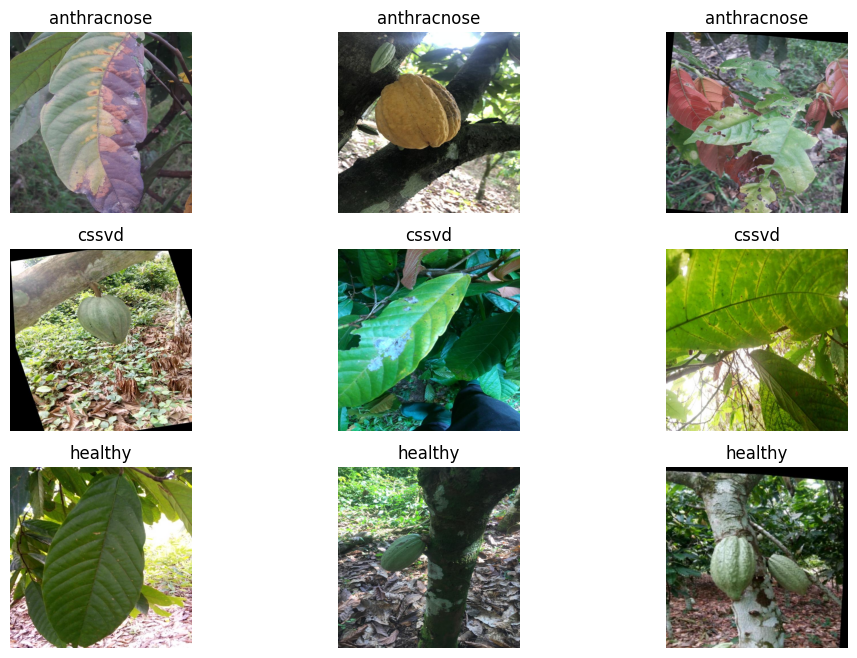

In [38]:
import cv2

base_path = "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (CNN and Resnet)/train"

classes = os.listdir(base_path)

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    class_path = os.path.join(base_path, cls)
    imgs = random.sample(os.listdir(class_path), 3)

    for j, img_name in enumerate(imgs):
        img_path = os.path.join(class_path, img_name)
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), 3, i*3 + j + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

In [39]:
import os

def count_dataset(base_path):

    print(f"\n📂 Dataset: {base_path}")

    total_all = 0

    for split in ['train', 'valid', 'test']:
        split_path = os.path.join(base_path, split)

        if not os.path.exists(split_path):
            print(f"\n⚠️ {split} tidak ditemukan")
            continue

        print(f"\n🔹 {split.upper()}")

        total_split = 0

        for cls in os.listdir(split_path):
            class_path = os.path.join(split_path, cls)

            if os.path.isdir(class_path):
                count = len([
                    f for f in os.listdir(class_path)
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
                ])

                print(f"{cls}: {count}")
                total_split += count

        print(f"➡️ Total {split}: {total_split}")
        total_all += total_split

    print(f"\n🔥 TOTAL DATASET: {total_all}")

In [40]:
count_dataset=("/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (CNN and Resnet)")

**Data Preprocessing**

In [7]:
#Set Parameter
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

base_path = "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (CNN and Resnet)/train"

classes = os.listdir(base_path)
img_size = (224, 224)

In [8]:
#Preprocessing Resize dan Normalization
def preprocess_image(img_path):
    # read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # resize
    resized = cv2.resize(img, img_size)

    # normalization
    normalized = resized / 255.0

    return img, resized, normalized

In [9]:
#Data Augmentation

def augment_image(image):
    image = image.copy()

    h, w = image.shape[:2]

    # ======================
    # 1. Horizontal Flip (masih OK)
    # ======================
    if random.random() > 0.5:
        image = np.fliplr(image)

    # ======================
    # 2. Rotasi (lebih realistis)
    # ======================
    angle = random.randint(-20, 20)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    image = cv2.warpAffine(image, M, (w, h))

    # ======================
    # 3. Zoom ringan
    # ======================
    scale = random.uniform(0.9, 1.1)
    M = cv2.getRotationMatrix2D((w//2, h//2), 0, scale)
    image = cv2.warpAffine(image, M, (w, h))

    # ======================
    # 4. Translasi (geser posisi)
    # ======================
    tx = random.randint(-10, 10)
    ty = random.randint(-10, 10)
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    image = cv2.warpAffine(image, M, (w, h))

    # ======================
    # 5. Brightness (lebih aman)
    # ======================
    image = np.clip(image * random.uniform(0.8, 1.2), 0, 255)

    return image.astype(np.uint8)

=== CONTOH NILAI PIXEL ===
Original min-max: 1 255
Normalized min-max: 0.00784313725490196 1.0
=== CONTOH NILAI PIXEL ===
Original min-max: 0 255
Normalized min-max: 0.0 1.0
=== CONTOH NILAI PIXEL ===
Original min-max: 0 255
Normalized min-max: 0.0 1.0


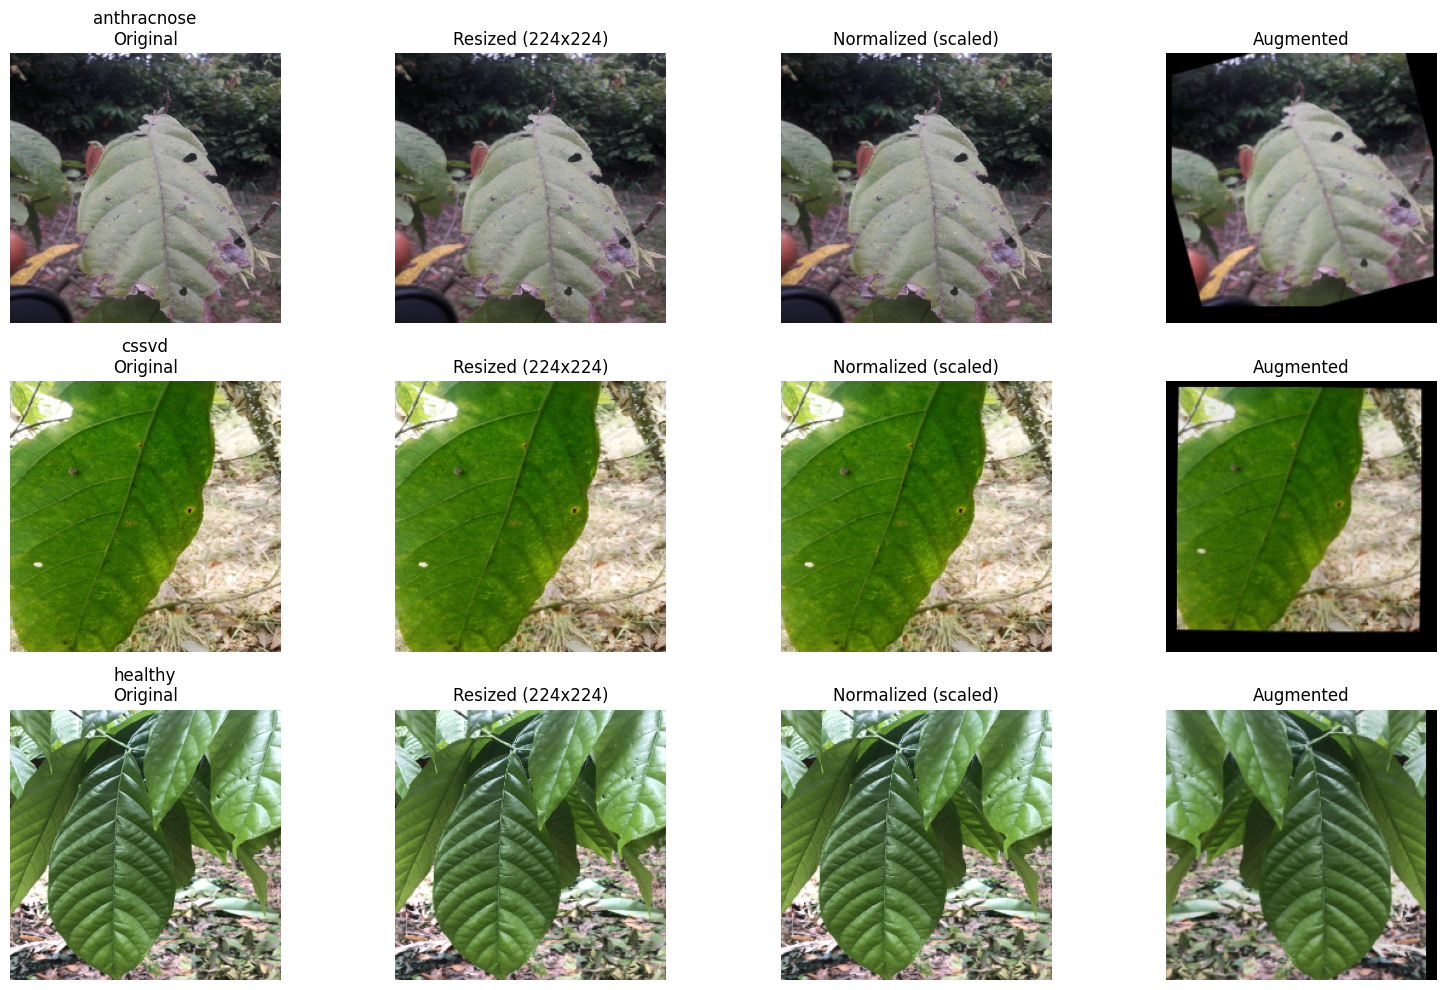

In [19]:
# VISUALISASI BEFORE vs AFTER (INI YANG PENTING)

plt.figure(figsize=(16, 10))

rows = len(classes)

for i, cls in enumerate(classes):
    class_path = os.path.join(base_path, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # preprocessing
    original, resized, normalized = preprocess_image(img_path)
    augmented = augment_image(resized)

    print("=== CONTOH NILAI PIXEL ===")
    print("Original min-max:", original.min(), original.max())
    print("Normalized min-max:", normalized.min(), normalized.max())

    # =========================
    # DISPLAY
    # =========================

    # ORIGINAL
    plt.subplot(rows, 4, i*4 + 1)
    plt.imshow(original)
    plt.title(f"{cls}\nOriginal")
    plt.axis('off')

    # RESIZED
    plt.subplot(rows, 4, i*4 + 2)
    plt.imshow(resized)
    plt.title("Resized (224x224)")
    plt.axis('off')

    # NORMALIZED (DI SCALE BIAR KELIHATAN)
    plt.subplot(rows, 4, i*4 + 3)
    plt.imshow((normalized * 255).astype(np.uint8))
    plt.title("Normalized (scaled)")
    plt.axis('off')

    # AUGMENTED
    plt.subplot(rows, 4, i*4 + 4)
    plt.imshow(augmented)
    plt.title("Augmented")
    plt.axis('off')

plt.tight_layout()
plt.show()

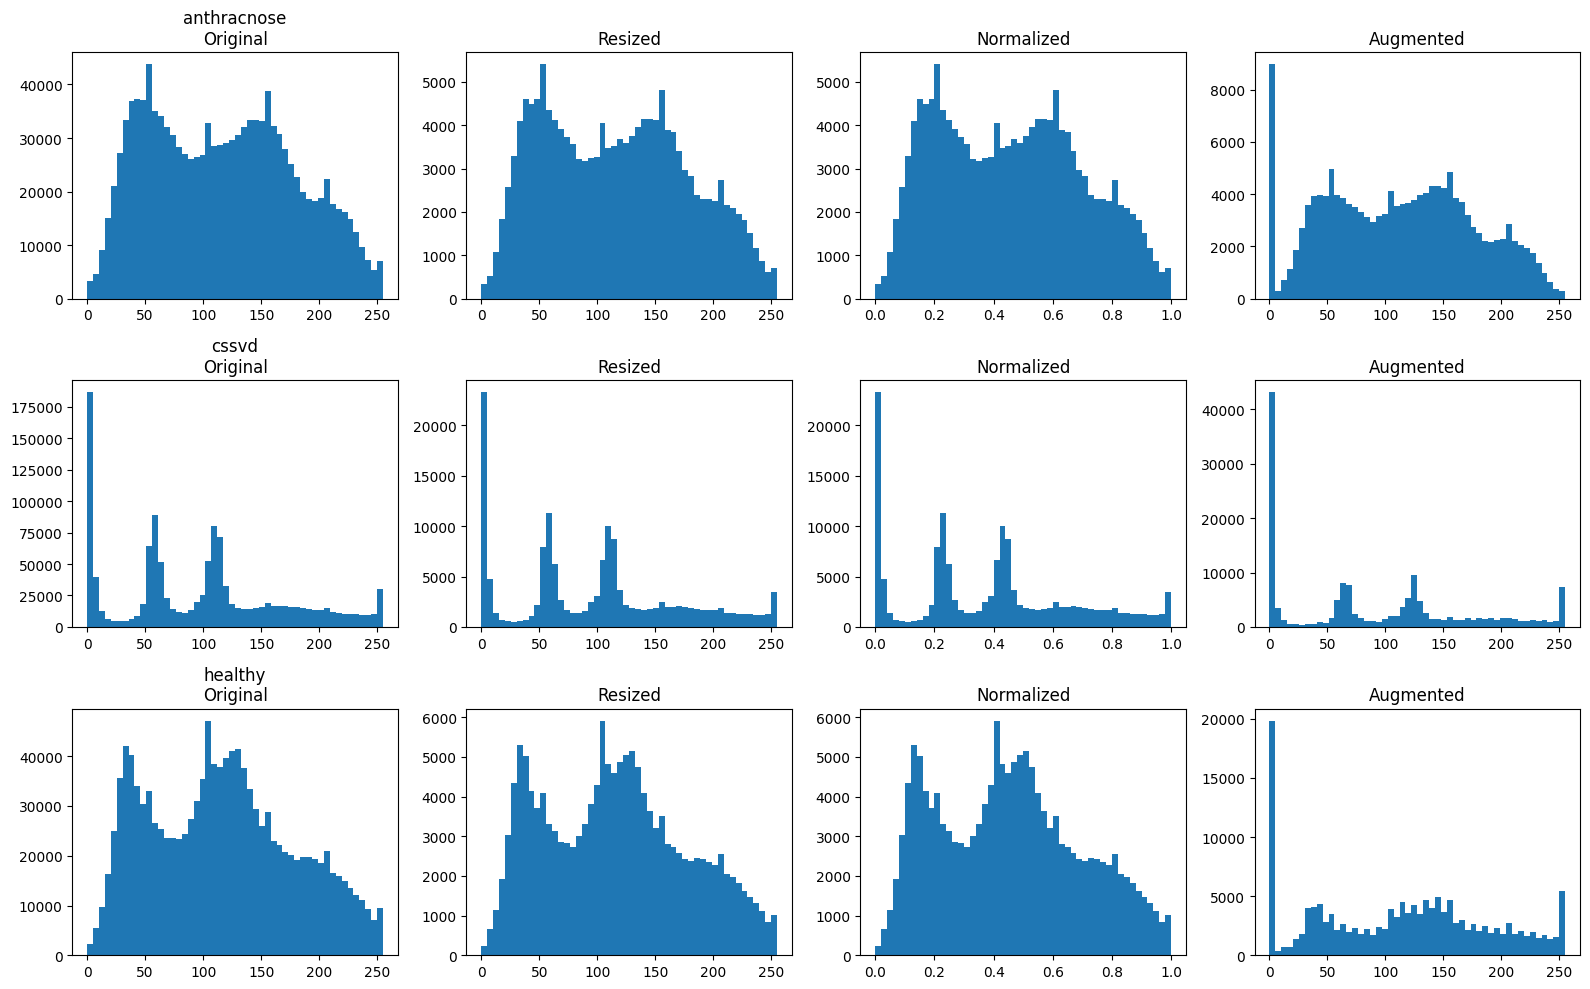

In [13]:
plt.figure(figsize=(16, 10))

rows = len(classes)

for i, cls in enumerate(classes):
    class_path = os.path.join(base_path, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # preprocessing
    original, resized, normalized = preprocess_image(img_path)
    augmented = augment_image(resized)

    # =========================
    # HISTOGRAM ORIGINAL
    # =========================
    plt.subplot(rows, 4, i*4 + 1)
    plt.hist(original.ravel(), bins=50)
    plt.title(f"{cls}\nOriginal")

    # =========================
    # HISTOGRAM RESIZED
    # =========================
    plt.subplot(rows, 4, i*4 + 2)
    plt.hist(resized.ravel(), bins=50)
    plt.title("Resized")

    # =========================
    # HISTOGRAM NORMALIZED
    # =========================
    plt.subplot(rows, 4, i*4 + 3)
    plt.hist(normalized.ravel(), bins=50)
    plt.title("Normalized")

    # =========================
    # HISTOGRAM AUGMENTED
    # =========================
    plt.subplot(rows, 4, i*4 + 4)
    plt.hist(augmented.ravel(), bins=50)
    plt.title("Augmented")

plt.tight_layout()
plt.show()

**Load Dataset (Tidak Split Data)**

In [14]:
train_path = "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (CNN and Resnet)/train"
valid_path = "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (CNN and Resnet)/valid"
test_path  = "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (CNN and Resnet)/test"

In [15]:
# Data Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # penting
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # penting
)

class_names = list(test_gen.class_indices.keys())

Found 3945 images belonging to 3 classes.
Found 563 images belonging to 3 classes.
Found 1018 images belonging to 3 classes.


**Train Model**

In [16]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

cnn_model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

cnn_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# freeze sebagian besar layer
base_model.trainable = True
for layer in base_model.layers[-30:]:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(len(train_gen.class_indices), activation='softmax')(x)

resnet_model = models.Model(inputs=base_model.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
cnn_history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1305s 10s/step - accuracy: 0.6025 - loss: 1.0028 - val_accuracy: 0.4014 - val_loss: 1.3137
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 91s 734ms/step - accuracy: 0.6439 - loss: 0.9149 - val_accuracy: 0.5151 - val_loss: 1.1425
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 658ms/step - accuracy: 0.6489 - loss: 0.8955 - val_accuracy: 0.5400 - val_loss: 1.1344
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 80s 645ms/step - accuracy: 0.6649 - loss: 0.8644 - val_accuracy: 0.6199 - val_loss: 0.8911
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 79s 641ms/step - accuracy: 0.6755 - loss: 0.8238 - val_accuracy: 0.6696 - val_loss: 0.8310
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 83s 645ms/step - accuracy: 0.6880 - loss: 0.8031 - val_accuracy: 0.5222 - val_loss: 1.3308
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 77s 623ms/step - accuracy: 0.6971 - loss: 0.7794 - val_accuracy: 0.5542 - val_loss: 1.1562
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 77s 621ms/step - accuracy: 0.7118 - loss: 0

In [19]:
resnet_history = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,

)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 174s 948ms/step - accuracy: 0.4489 - loss: 1.2394 - val_accuracy: 0.3481 - val_loss: 2.8838
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 89s 719ms/step - accuracy: 0.6079 - loss: 0.8975 - val_accuracy: 0.3481 - val_loss: 6.3596
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 89s 715ms/step - accuracy: 0.6996 - loss: 0.7133 - val_accuracy: 0.3481 - val_loss: 3.7387
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 89s 719ms/step - accuracy: 0.7389 - loss: 0.6398 - val_accuracy: 0.3499 - val_loss: 3.8390
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 88s 707ms/step - accuracy: 0.7643 - loss: 0.5782 - val_accuracy: 0.4245 - val_loss: 1.9266
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 89s 715ms/step - accuracy: 0.7952 - loss: 0.5188 - val_accuracy: 0.5222 - val_loss: 1.1886
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 89s 715ms/step - accuracy: 0.8068 - loss: 0.4847 - val_accuracy: 0.6679 - val_loss: 0.8066
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 93s 751ms/step - accuracy: 0.8213 - loss: 

In [20]:
yolo_model = YOLO('yolov8n.pt')

yolo_model.train(
    data="/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (Yolov8)/data.yaml",  # train + val + test
    epochs=20,
    imgsz=640,

    # INI YANG PENTING
    project="/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (Yolov8)/results",
    name="exp_yolo"
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (Yolov8)/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_yolo, nbs=64, nms

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fde01494920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [21]:
import collections

train_count = collections.Counter(train_gen.classes)
val_count = collections.Counter(val_gen.classes)
test_count = collections.Counter(test_gen.classes)

print("TRAIN distribution:", train_count)
print("VAL distribution:", val_count)
print("TEST distribution:", test_count)

TRAIN distribution: Counter({np.int32(1): 1584, np.int32(2): 1226, np.int32(0): 1135})
VAL distribution: Counter({np.int32(1): 196, np.int32(0): 184, np.int32(2): 183})
TEST distribution: Counter({np.int32(1): 441, np.int32(2): 317, np.int32(0): 260})


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate(model, test_gen, title):

    y_pred = model.predict(test_gen)
    y_pred = np.argmax(y_pred, axis=1)
    y_true = test_gen.classes

    labels = list(test_gen.class_indices.keys())

    print(f"\n===== {title} Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=labels))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy_score(y_true, y_pred)

In [23]:
y_pred = np.argmax(cnn_model.predict(val_gen), axis=1)

print("Predicted distribution:")
print(collections.Counter(y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step
Predicted distribution:
Counter({np.int64(1): 313, np.int64(0): 182, np.int64(2): 68})


32/32 ━━━━━━━━━━━━━━━━━━━━ 358s 12s/step

===== CNN Classification Report =====
              precision    recall  f1-score   support

 anthracnose       0.68      0.73      0.70       260
       cssvd       0.64      0.92      0.75       441
     healthy       0.72      0.24      0.36       317

    accuracy                           0.66      1018
   macro avg       0.68      0.63      0.60      1018
weighted avg       0.67      0.66      0.62      1018



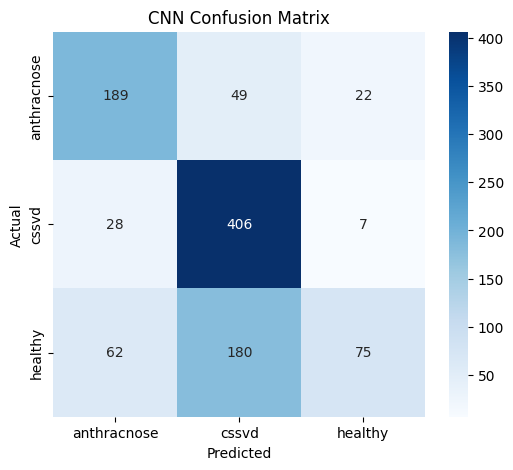

In [24]:
cnn_acc = evaluate(cnn_model, test_gen, "CNN")

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 406ms/step

===== ResNet50 Classification Report =====
              precision    recall  f1-score   support

 anthracnose       0.85      0.88      0.86       260
       cssvd       0.87      0.89      0.88       441
     healthy       0.88      0.83      0.85       317

    accuracy                           0.87      1018
   macro avg       0.87      0.87      0.87      1018
weighted avg       0.87      0.87      0.87      1018



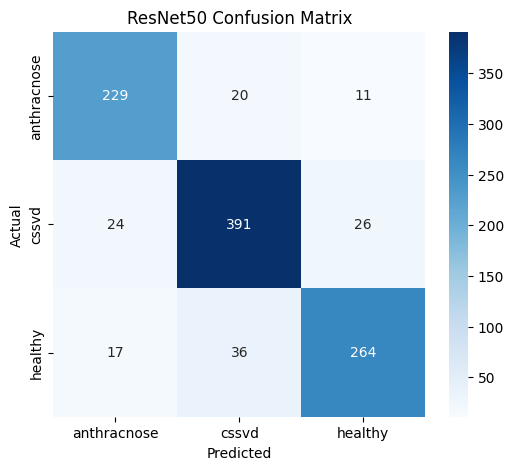

In [25]:
resnet_acc = evaluate(resnet_model, test_gen, "ResNet50")

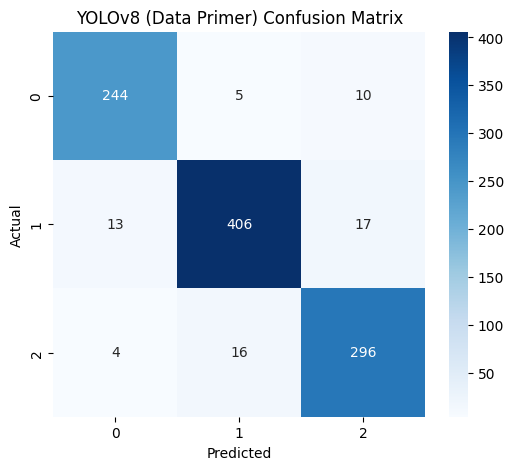

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

yolo_test_img = "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (Yolov8)/test/images"
yolo_test_lbl = "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (Yolov8)/test/labels"

def get_label(path):
    if not os.path.exists(path):
        return -1
    return int(open(path).read().split()[0])

def plot_cm(y_true, y_pred, title, labels=None):
    if labels is None:
        labels = sorted(list(set(y_true) | set(y_pred)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

yolo_true, yolo_pred = [], []

for img_name in os.listdir(yolo_test_img):
    img_path = os.path.join(yolo_test_img, img_name)
    label_path = os.path.join(yolo_test_lbl, img_name.replace('.jpg','.txt'))

    # ground truth
    true_cls = get_label(label_path)
    yolo_true.append(true_cls)

    # prediksi
    result = yolo_model(img_path, verbose=False)

    if len(result[0].boxes) > 0:
        conf = result[0].boxes.conf.cpu().numpy()
        cls  = result[0].boxes.cls.cpu().numpy().astype(int)

        pred_cls = cls[np.argmax(conf)]
    else:
        pred_cls = -1

    yolo_pred.append(pred_cls)

# filter valid
f_true, f_pred = [], []
for t,p in zip(yolo_true,yolo_pred):
    if t != -1 and p != -1:
        f_true.append(t)
        f_pred.append(p)

plot_cm(f_true, f_pred, "YOLOv8 (Data Primer)")

In [27]:
def yolo_to_classification(model, images_path, labels_path):
    image_files = sorted(os.listdir(images_path))

    y_true = []
    y_pred = []

    for img_file in image_files:
        img_path = os.path.join(images_path, img_file)

        # ====== GROUND TRUTH ======
        label_file = img_file.replace('.jpg', '.txt')
        label_path = os.path.join(labels_path, label_file)

        if not os.path.exists(label_path):
            continue

        with open(label_path, 'r') as f:
            line = f.readline().strip()
            true_class = int(line.split()[0])

        # ====== PREDIKSI YOLO ======
        results = model(img_path, verbose=False)[0]

        if len(results.boxes) > 0:
            confs = results.boxes.conf.cpu().numpy()
            classes = results.boxes.cls.cpu().numpy()

            best_idx = np.argmax(confs)
            pred_class = int(classes[best_idx])
        else:
            pred_class = -1  # gagal deteksi

        y_true.append(true_class)
        y_pred.append(pred_class)

    return np.array(y_true), np.array(y_pred)

In [28]:
y_true_yolo, y_pred_yolo = yolo_to_classification(
    yolo_model,
    yolo_test_img,
    yolo_test_lbl
)

In [29]:
mask = y_pred_yolo != -1

y_true_yolo = y_true_yolo[mask]
y_pred_yolo = y_pred_yolo[mask]

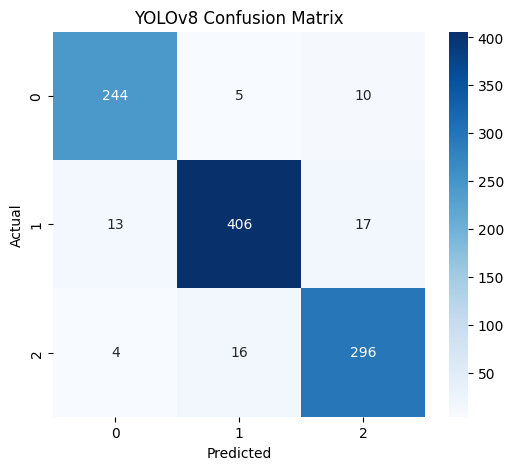

In [30]:
plot_cm(y_true_yolo, y_pred_yolo, "YOLOv8")

In [31]:
from sklearn.metrics import classification_report

labels = ["anthracnose", "cssvd", "healthy"]

print("\n===== YOLOv8 Classification Report =====")
print(classification_report(y_true_yolo, y_pred_yolo, target_names=labels))


===== YOLOv8 Classification Report =====
              precision    recall  f1-score   support

 anthracnose       0.93      0.94      0.94       259
       cssvd       0.95      0.93      0.94       436
     healthy       0.92      0.94      0.93       316

    accuracy                           0.94      1011
   macro avg       0.93      0.94      0.94      1011
weighted avg       0.94      0.94      0.94      1011



In [32]:
from sklearn.metrics import accuracy_score

yolo_acc = accuracy_score(y_true_yolo, y_pred_yolo)

print("YOLO Accuracy:", yolo_acc)

YOLO Accuracy: 0.9357072205736894


In [33]:
import pandas as pd

yolo_results = pd.read_csv(
    "/content/drive/MyDrive/Project Individu Deep Learning/Dataset Daun Kokoa/Dataset Daun Kokoa (Yolov8)/results/exp_yolo/results.csv"
)

yolo_results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,93.6745,1.29911,2.27583,1.66886,0.32806,0.34434,0.26429,0.12530,1.64295,2.85794,2.03956,0.000474,0.000474,0.000474
1,2,182.8790,1.33452,1.86056,1.67812,0.57912,0.47834,0.47611,0.25466,1.62936,1.94782,2.06664,0.000904,0.000904,0.000904
2,3,271.5220,1.33052,1.75486,1.66665,0.46363,0.36451,0.31075,0.17194,1.57080,2.35601,2.03266,0.001286,0.001286,0.001286
3,4,360.2830,1.31113,1.68439,1.65270,0.65005,0.43251,0.51421,0.29931,1.52149,1.77802,1.93220,0.001217,0.001217,0.001217
4,5,449.1020,1.27669,1.60951,1.62996,0.61836,0.47710,0.54066,0.31140,1.55935,1.77251,1.92713,0.001146,0.001146,0.001146


In [34]:
import collections

print("Distribusi Prediksi YOLO:")
print(collections.Counter(y_pred_yolo))

Distribusi Prediksi YOLO:
Counter({np.int64(1): 427, np.int64(2): 323, np.int64(0): 261})


In [35]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN", "ResNet50", "YOLOv8"],
    "Accuracy": [cnn_acc, resnet_acc, yolo_acc]
})

print(results)

      Model  Accuracy
0       CNN  0.658153
1  ResNet50  0.868369
2    YOLOv8  0.935707


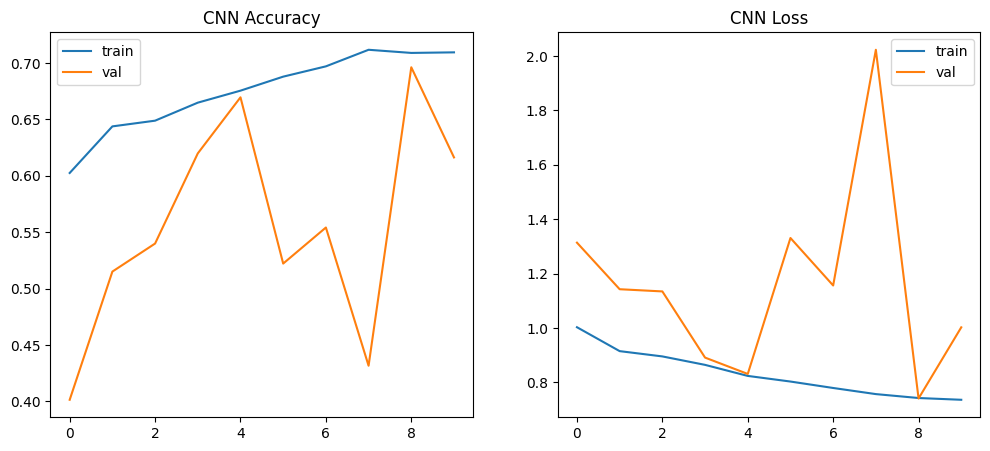

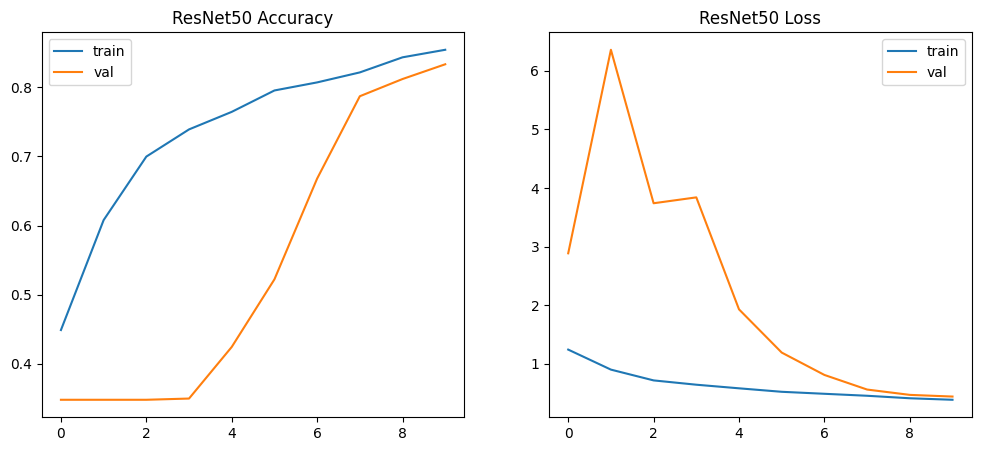

In [36]:
import matplotlib.pyplot as plt

def plot(history, title):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.legend(['train','val'])

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.legend(['train','val'])

    plt.show()

plot(cnn_history, "CNN")
plot(resnet_history, "ResNet50")

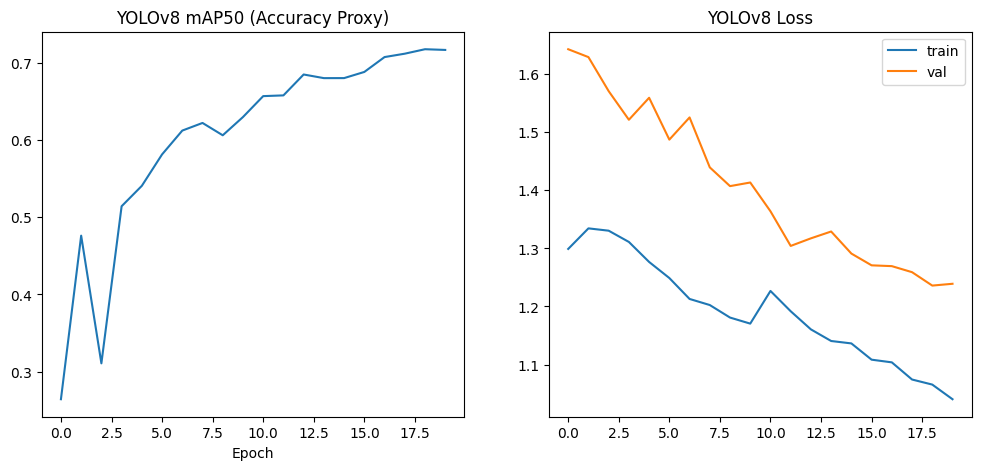

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# 🔹 Accuracy analog (pakai mAP50)
plt.subplot(1,2,1)
plt.plot(yolo_results['metrics/mAP50(B)'])
plt.title("YOLOv8 mAP50 (Accuracy Proxy)")
plt.xlabel("Epoch")

# 🔹 Loss
plt.subplot(1,2,2)
plt.plot(yolo_results['train/box_loss'])
plt.plot(yolo_results['val/box_loss'])
plt.title("YOLOv8 Loss")
plt.legend(['train','val'])

plt.show()

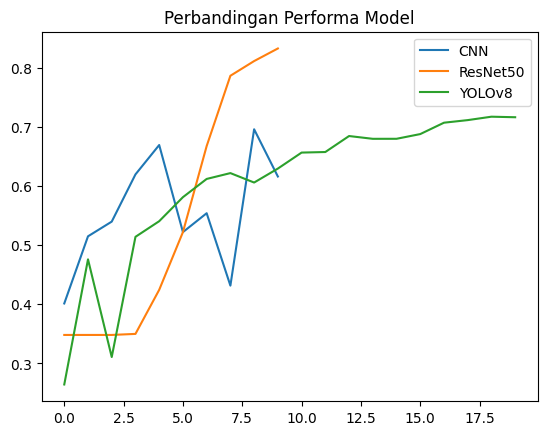

In [38]:
plt.figure()

plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(resnet_history.history['val_accuracy'], label='ResNet50')
plt.plot(yolo_results['metrics/mAP50(B)'], label='YOLOv8')

plt.title("Perbandingan Performa Model")
plt.legend()
plt.show()

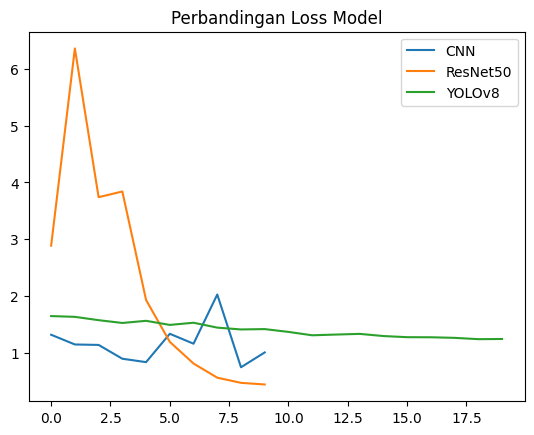

In [39]:
plt.figure()

plt.plot(cnn_history.history['val_loss'], label='CNN')
plt.plot(resnet_history.history['val_loss'], label='ResNet50')
plt.plot(yolo_results['val/box_loss'], label='YOLOv8')

plt.title("Perbandingan Loss Model")
plt.legend()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.6582 - loss: 0.9063
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step - accuracy: 0.8684 - loss: 0.3540
      Model  Accuracy
2    YOLOv8  0.935707
1  ResNet50  0.868369
0       CNN  0.658153


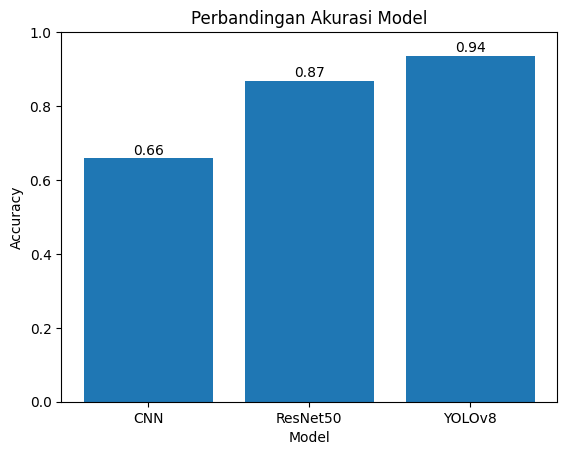

In [40]:
cnn_acc = cnn_model.evaluate(test_gen)[1]
resnet_acc = resnet_model.evaluate(test_gen)[1]
yolo_acc = accuracy_score(f_true, f_pred)

import pandas as pd

results = pd.DataFrame({
    "Model":["CNN","ResNet50","YOLOv8"],
    "Accuracy":[cnn_acc,resnet_acc,yolo_acc]
})

print(results.sort_values(by="Accuracy",ascending=False))

plt.figure()

plt.bar(results["Model"], results["Accuracy"])

plt.title("Perbandingan Akurasi Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")

# tampilkan nilai di atas bar
for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0,1)
plt.show()

**Prediksi Contoh Citra Dengan 3 Model**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1000ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
=== HASIL KLASIFIKASI ===
CNN     : cssvd (0.99)
ResNet  : cssvd (0.99)
YOLOv8  : cssvd (0.84)


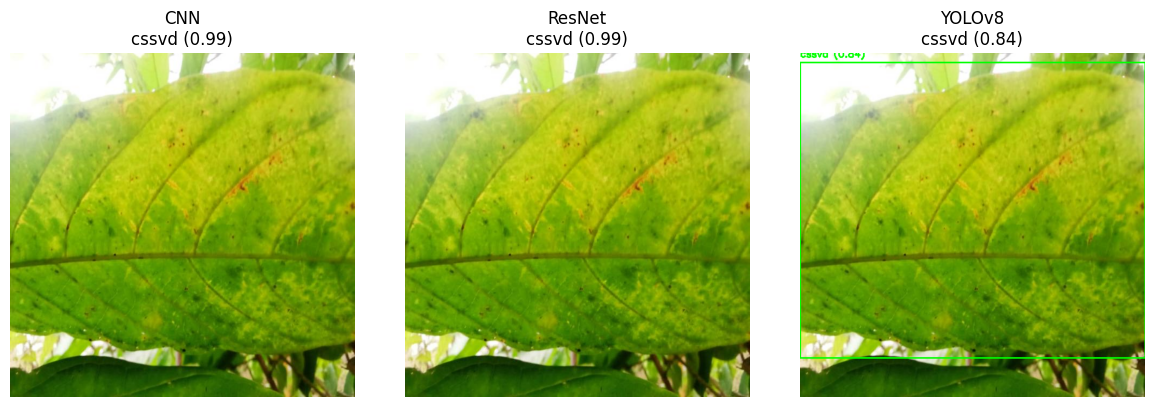

In [41]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ambil gambar random
img_path = random.choice(test_gen.filepaths)

# load gambar
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

# ========================
# 🔹 PREPROCESS CNN & RESNET
# ========================
img_resized = cv2.resize(img, (224,224)) / 255.0
img_input = np.expand_dims(img_resized, axis=0)

# CNN
pred_cnn = cnn_model.predict(img_input)
cnn_class = class_names[np.argmax(pred_cnn)]
cnn_conf  = np.max(pred_cnn)

# ResNet
pred_resnet = resnet_model.predict(img_input)
resnet_class = class_names[np.argmax(pred_resnet)]
resnet_conf  = np.max(pred_resnet)

# ========================
# 🔴 YOLO
# ========================
yolo_result = yolo_model(img_path, verbose=False)

img_yolo = img.copy()

if len(yolo_result[0].boxes) > 0:
    boxes = yolo_result[0].boxes.xyxy.cpu().numpy()
    confs = yolo_result[0].boxes.conf.cpu().numpy()
    classes_yolo = yolo_result[0].boxes.cls.cpu().numpy().astype(int)

    # ambil prediksi terbaik (confidence tertinggi)
    best_idx = np.argmax(confs)
    yolo_class = class_names[classes_yolo[best_idx]]
    yolo_conf  = confs[best_idx]

    # gambar semua bounding box
    for box, conf, cls in zip(boxes, confs, classes_yolo):
        x1, y1, x2, y2 = map(int, box)
        label = f"{class_names[cls]} ({conf:.2f})"

        cv2.rectangle(img_yolo, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img_yolo, label,
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0,255,0),
                    2)
else:
    yolo_class = "Tidak terdeteksi"
    yolo_conf  = 0

# ========================
# 🖨️ OUTPUT TEXT
# ========================
print("=== HASIL KLASIFIKASI ===")
print(f"CNN     : {cnn_class} ({cnn_conf:.2f})")
print(f"ResNet  : {resnet_class} ({resnet_conf:.2f})")
print(f"YOLOv8  : {yolo_class} ({yolo_conf:.2f})")

# ========================
# 📊 VISUALISASI
# ========================
plt.figure(figsize=(12,4))

# CNN
plt.subplot(1,3,1)
plt.imshow(img)
plt.title(f"CNN\n{cnn_class} ({cnn_conf:.2f})")
plt.axis('off')

# ResNet
plt.subplot(1,3,2)
plt.imshow(img)
plt.title(f"ResNet\n{resnet_class} ({resnet_conf:.2f})")
plt.axis('off')

# YOLO
plt.subplot(1,3,3)
plt.imshow(img_yolo)
plt.title(f"YOLOv8\n{yolo_class} ({yolo_conf:.2f})")
plt.axis('off')

plt.tight_layout()
plt.show()